# Web Agent Classification 


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.base import clone

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SVMSMOTE, SMOTENC, SMOTEN

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_ESTIMATORS = 500
N_JOBS = -1
K_NEIGHBORS = 5

TARGET_COL = "Agent"

META_COLS = [
    "Web Agent", "tool", "Special prompt", "category", "_id", "timestamp", "siteKey", "jsFP", 
    "cookieId", "Agent", "Agent LOCAL/CLOUD"
]

LABELS = [
    "Human",
    "Selenium",
    "Playwright", 
    "Puppeteer",
    "OpenClaw",
    "Antropic Claude for Chrome",
    "Crawl4AI",
    "Crawl4AI_Stealth",
    "Crawl4AI_Undetected_Browser",
    "BrowserUse_LOCAL",
    "BrowserUse_CLOUD",
    "BrowserUse_Stealth",
    "ChatGPT Agent",
    "Skyvern"
]
layers = ["TLS", "IP", "BrowserFP", "TLS+IP", "All"]

## 1. Data loading and basic preprocessing

In [ ]:
def print_summary(df: pd.DataFrame, target: str) -> pd.DataFrame:
    summary = (
        df.groupby(target)
        .agg(
            num_fingerprints=("_id", "count"),
            jsFP_true=("jsFP", lambda x: (x == True).sum()),
            jsFP_false=("jsFP", lambda x: (x == False).sum()),
        )
        .reset_index()
    )
    summary["percent"] = (summary["num_fingerprints"] / len(df) * 100).round(2)
    return summary.sort_values("num_fingerprints", ascending=False)


def process_column(col: pd.Series) -> pd.Series:
    """Convert a feature column to numeric when possible; otherwise keep it categorical."""
    col = col.replace("", "MISSING").fillna("MISSING")
    non_missing = col[col != "MISSING"]

    if len(non_missing) == 0:
        return col.astype(str)

    numeric_values = pd.to_numeric(non_missing, errors="coerce")
    is_numeric = numeric_values.notna().all()

    if is_numeric:
        col_numeric = pd.to_numeric(col.replace("MISSING", np.nan), errors="coerce")
        return col_numeric.fillna(-1)

    return col.astype(str)


def preprocess_browser_fingerprints(path: str = "active_tests_browser_layers.csv") -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.replace("", "MISSING").fillna("MISSING")

    # Keep only rows where browser fingerprinting attributes exist.
    df = df[df["jsFP"] == True].copy()

    for col in df.columns:
        if col not in META_COLS:
            df[col] = process_column(df[col])

    return df

In [ ]:
df_processed = preprocess_browser_fingerprints("active_tests_browser_layers.csv")

print(f"Processed dataset shape: {df_processed.shape}")
display(print_summary(df_processed, TARGET_COL))
print(df_processed.dtypes.value_counts())

Processed dataset shape: (1370, 152)


,Agent,num_fingerprints,jsFP_true,jsFP_false,percent
13,Skyvern,206,206,0,15.04
2,BrowserUse_LOCAL,130,130,0,9.49
1,BrowserUse_CLOUD,128,128,0,9.34
0,Antropic Claude for Chrome,124,124,0,9.05
3,BrowserUse_Stealth,120,120,0,8.76
9,OpenClaw,108,108,0,7.88
10,Playwright,100,100,0,7.30
12,Selenium,100,100,0,7.30
11,Puppeteer,99,99,0,7.23
4,ChatGPT Agent,65,65,0,4.74


str        110
int64       24
float64     17
bool         1
Name: count, dtype: int64


## 2. Merge IP/TLS features

In [ ]:
def add_network_features(
    df_processed: pd.DataFrame,
    pcap_path: str = "active_tests_with_TLS_IP_layers.csv",
) -> pd.DataFrame:
    df_pcaps = pd.read_csv(pcap_path)
    df_pcaps = df_pcaps[["_id", "client_ip", "ip_asn_name_log", "ja4"]]
    df_final = df_processed.merge(df_pcaps, on="_id", how="left")
    df_final = df_final.fillna("MISSING")
    return df_final


df_final = add_network_features(df_processed)
print(f"Final dataset shape after merging: {df_final.shape}")
display(print_summary(df_final, TARGET_COL))

Final dataset shape after merging: (1370, 155)


,Agent,num_fingerprints,jsFP_true,jsFP_false,percent
13,Skyvern,206,206,0,15.04
2,BrowserUse_LOCAL,130,130,0,9.49
1,BrowserUse_CLOUD,128,128,0,9.34
0,Antropic Claude for Chrome,124,124,0,9.05
3,BrowserUse_Stealth,120,120,0,8.76
9,OpenClaw,108,108,0,7.88
10,Playwright,100,100,0,7.30
12,Selenium,100,100,0,7.30
11,Puppeteer,99,99,0,7.23
4,ChatGPT Agent,65,65,0,4.74


## 3. Layer definitions

In [5]:
LAYER_CONFIGS = {
    "IP": ["client_ip", "ip_asn_name_log"],
    "TLS": ["ja4"],   
    "BrowserFP": None,  # all browser fingerprinting features except metadata and network features
    "TLS+IP": ["ja4", "client_ip", "ip_asn_name_log"],
    "All": None,        # all available features except metadata
}

NETWORK_COLS = ["ja4", "client_ip", "ip_asn_name_log"]


def get_feature_columns(df: pd.DataFrame, layer_name: str) -> list[str]:
    if layer_name not in LAYER_CONFIGS:
        raise ValueError(f"Unknown layer: {layer_name}")

    configured_cols = LAYER_CONFIGS[layer_name]

    if layer_name == "BrowserFP":
        return [
            c for c in df.columns
            if c not in META_COLS and c not in NETWORK_COLS
        ]

    if layer_name == "All":
        return [c for c in df.columns if c not in META_COLS]

    return configured_cols


def make_layer_dataset(df: pd.DataFrame, layer_name: str, target_col: str = TARGET_COL):
    feature_cols = get_feature_columns(df, layer_name)
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y

## 4. Encoding helpers for non-CatBoost models

In [6]:
def sanitize_feature_names(columns):
    import re
    from collections import Counter

    cleaned = []
    for col in columns:
        col = str(col)
        col = re.sub(r"[\[\]<>]", "_", col)
        col = re.sub(r"\s+", "_", col)
        cleaned.append(col)

    counts = Counter()
    unique_cols = []
    for col in cleaned:
        counts[col] += 1
        unique_cols.append(col if counts[col] == 1 else f"{col}_{counts[col]}")

    return unique_cols


def get_categorical_columns(X: pd.DataFrame) -> list[str]:
    return X.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()


def encode_features(X_train, X_test, method="none"):
    """
    Encoding methods:
    - none: keep raw dataframe, intended for CatBoost
    - dummies: one-hot encoding
    - label: ordinal encoding
    - frequency: frequency encoding
    """
    X_train = X_train.copy()
    X_test = X_test.copy()

    cat_cols = get_categorical_columns(X_train)

    for col in cat_cols:
        X_train[col] = X_train[col].astype("string").fillna("MISSING")
        X_test[col] = X_test[col].astype("string").fillna("MISSING")

    if method == "none":
        return X_train, X_test, cat_cols

    if method == "dummies":
        X_train_enc = pd.get_dummies(X_train, columns=cat_cols, dummy_na=False, dtype=int)
        X_test_enc = pd.get_dummies(X_test, columns=cat_cols, dummy_na=False, dtype=int)
        X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

    elif method == "label":
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_train_enc = X_train.copy()
        X_test_enc = X_test.copy()
        X_train_enc[cat_cols] = encoder.fit_transform(X_train[cat_cols])
        X_test_enc[cat_cols] = encoder.transform(X_test[cat_cols])

    elif method == "frequency":
        X_train_enc = X_train.copy()
        X_test_enc = X_test.copy()
        for col in cat_cols:
            freq = X_train[col].value_counts(normalize=True)
            X_train_enc[col] = X_train[col].map(freq).fillna(0)
            X_test_enc[col] = X_test[col].map(freq).fillna(0)

    else:
        raise ValueError("Unknown encoding method")

    clean_cols = sanitize_feature_names(X_train_enc.columns)
    X_train_enc.columns = clean_cols
    X_test_enc.columns = clean_cols

    return X_train_enc, X_test_enc, []

## 5. Models and optional resampling

In [7]:
def make_model(model_name: str, seed: int = RANDOM_STATE):
    if model_name == "RF":
        return RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            random_state=seed,
            n_jobs=N_JOBS,
        )

    if model_name == "RF_balanced":
        return RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            class_weight="balanced",
            random_state=seed,
            n_jobs=N_JOBS,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            n_estimators=N_ESTIMATORS,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=N_JOBS,
        )

    if model_name == "CatBoost":
        return CatBoostClassifier(
            loss_function="MultiClass",
            iterations=500,
            learning_rate=0.05,
            depth=6,
            auto_class_weights="Balanced",
            random_seed=seed,
            verbose=False,
        )

    raise ValueError(f"Unknown model: {model_name}")


def make_sampler(name, X_train: pd.DataFrame, cat_cols: list[str], seed: int, k_neighbors: int = K_NEIGHBORS):
    if name is None:
        return None

    if name == "SMOTE":
        return SMOTE(random_state=seed, k_neighbors=k_neighbors)

    if name == "BL_SMOTE":
        return BorderlineSMOTE(random_state=seed, k_neighbors=k_neighbors, kind="borderline-1")

    if name == "SVMSMOTE":
        return SVMSMOTE(random_state=seed, k_neighbors=k_neighbors)

    if name == "SMOTENC":
        # SMOTENC requires mixed numerical + categorical features.
        categorical_indices = [X_train.columns.get_loc(c) for c in cat_cols]
        if len(categorical_indices) == 0:
            return SMOTE(random_state=seed, k_neighbors=k_neighbors)
        if len(categorical_indices) == X_train.shape[1]:
            return SMOTEN(random_state=seed, k_neighbors=k_neighbors)
        return SMOTENC(
            categorical_features=categorical_indices,
            random_state=seed,
            k_neighbors=k_neighbors,
        )

    raise ValueError(f"Unknown sampler: {name}")

## 6. One experiment function

In [8]:
def evaluate_predictions(y_true, y_pred, labels=LABELS) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "cm": confusion_matrix(y_true, y_pred, labels=labels),
    }

def run_experiment(
    df: pd.DataFrame,
    layer_name: str,
    model_name: str = "CatBoost",
    encoding: str = "none",
    sampler_name: str | None = None,
    seed: int = RANDOM_STATE,
    test_size: float = TEST_SIZE,
):
    X, y = make_layer_dataset(df, layer_name)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )

    # XGBoost requires numerical class labels.
    y_encoder = None
    if model_name == "XGBoost":
        y_encoder = LabelEncoder()
        y_train_model = y_encoder.fit_transform(y_train)
        y_test_model = y_encoder.transform(y_test)
    else:
        y_train_model = y_train
        y_test_model = y_test

    X_train_enc, X_test_enc, cat_cols = encode_features(X_train, X_test, method=encoding)

    sampler = make_sampler(sampler_name, X_train_enc, cat_cols, seed=seed)
    if sampler is not None:
        X_train_enc, y_train_model = sampler.fit_resample(X_train_enc, y_train_model)

    model = make_model(model_name, seed=seed)

    if model_name == "CatBoost" and encoding == "none":
        model.fit(X_train_enc, y_train_model, cat_features=cat_cols)
    else:
        model.fit(X_train_enc, y_train_model)

    y_pred = model.predict(X_test_enc)

    if model_name == "XGBoost":
        y_pred = y_encoder.inverse_transform(y_pred.astype(int))
        y_test_eval = y_test
    else:
        y_test_eval = y_test_model

    metrics = evaluate_predictions(y_test_eval, y_pred)

    result = {
        "layer": layer_name,
        "model": model_name,
        "encoding": encoding,
        "sampler": sampler_name or "None",
        "seed": seed,
        "n_train": len(X_train_enc),
        "n_test": len(X_test_enc),
        **metrics,
        "classification_report": classification_report(
            y_test_eval, y_pred, zero_division=0, output_dict=True
        ),
        "trained_model": model,
    }

    return result

## 7. Classification using three classifiers

In [ ]:
EXPERIMENTS = [
    # model, encoding, sampler
    ("RF", "dummies", None),
    ("RF", "label", None),
    ("RF", "frequency", None),
    
    ("RF_balanced", "dummies", None),
    ("RF_balanced", "label", None),
    ("RF_balanced", "frequency", None),
    
    ("RF", "dummies", "SMOTE"),
    ("RF", "label", "SMOTE"),
    ("RF", "frequency", "SMOTE"),
    
    ("RF", "dummies", "BL_SMOTE"),
    ("RF", "label", "BL_SMOTE"),
    ("RF", "frequency", "BL_SMOTE"),
    
    ("RF", "dummies", "SVMSMOTE"),
    ("RF", "label", "SVMSMOTE"),
    ("RF", "frequency", "SVMSMOTE"),
    
    ("XGBoost", "dummies", None),
    ("XGBoost", "dummies", "SMOTE"),
    ("XGBoost", "dummies", "BL_SMOTE"),
    ("XGBoost", "dummies", "SVMSMOTE"),
    
    ("CatBoost", "none", "SMOTENC"),
]

all_results = []
for layer in layers:
    for model_name, encoding, sampler_name in EXPERIMENTS:
        try:
            result = run_experiment(
                df=df_final,
                layer_name=layer,
                model_name=model_name,
                encoding=encoding,
                sampler_name=sampler_name,
                seed=RANDOM_STATE,
            )
            all_results.append(result)
        except Exception as e:
            print(f"FAILED: layer={layer}, model={model_name}, encoding={encoding}, sampler={sampler_name}: {e}")

summary = (
    pd.DataFrame(all_results)
    .drop(columns=["classification_report", "trained_model"])
    .sort_values(["accuracy", "layer"], ascending=False)
    .reset_index(drop=True)
)

display(summary)

FAILED: layer=IP, model=RF, encoding=label, sampler=SVMSMOTE: All support vectors are considered as noise. SVM-SMOTE is not adapted to your dataset. Try another SMOTE variant.


,layer,model,encoding,sampler,seed,n_train,n_test,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,cm
0,All,RF,dummies,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
1,All,RF,frequency,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
2,All,RF_balanced,dummies,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
3,All,RF_balanced,frequency,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
4,All,RF,dummies,SMOTE,42,2310,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,TLS,CatBoost,none,SMOTENC,42,2310,274,0.408759,0.355689,0.408284,0.336506,0.406148,0.408759,0.355982,"[[3, 0, 0, 0, 2, 0, 3, 0, 0, 0, 0, 0, 0, 0], [..."
95,TLS,RF,frequency,SMOTE,42,2310,274,0.383212,0.327821,0.378232,0.302201,0.375711,0.383212,0.319454,"[[3, 0, 0, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0], [..."
96,TLS,RF,frequency,SVMSMOTE,42,1810,274,0.372263,0.364791,0.374218,0.310339,0.416283,0.372263,0.328818,"[[1, 0, 2, 0, 2, 0, 0, 3, 0, 0, 0, 0, 0, 0], [..."
97,TLS,RF,frequency,BL_SMOTE,42,2197,274,0.368613,0.320678,0.381361,0.295399,0.361194,0.368613,0.302770,"[[3, 0, 0, 0, 2, 0, 0, 3, 0, 0, 0, 0, 0, 0], [..."


In [ ]:
summary.head(50)

,layer,model,encoding,sampler,seed,n_train,n_test,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,cm
0,All,RF,dummies,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
1,All,RF,frequency,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
2,All,RF_balanced,dummies,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
3,All,RF_balanced,frequency,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
4,All,RF,dummies,SMOTE,42,2310,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
5,All,RF,frequency,SMOTE,42,2310,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
6,All,RF,frequency,BL_SMOTE,42,2197,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
7,All,RF,dummies,SVMSMOTE,42,2233,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
8,All,RF,frequency,SVMSMOTE,42,2233,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."
9,All,XGBoost,dummies,None,42,1096,274,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,"[[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [..."


## 8. Multi-seed evaluation of Random Forest classifier

In [ ]:
def run_multi_seed_experiment(
    df: pd.DataFrame,
    layer_name: str,
    model_name: str = "CatBoost",
    encoding: str = "none",
    sampler_name: str | None = None,
    seeds: list[int] | None = None,
):
    if seeds is None:
        seeds = [0, 1, 2, 3, 4, 42, 100, 123, 2024, 2026]

    rows = []
    for seed in seeds:
        result = run_experiment(
            df=df,
            layer_name=layer_name,
            model_name=model_name,
            encoding=encoding,
            sampler_name=sampler_name,
            seed=seed,
        )
        rows.append({
            k: v for k, v in result.items()
            if k not in ["classification_report", "trained_model"]
        })

    raw = pd.DataFrame(rows)

    metric_cols = [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "cm"
    ]

    aggregated = (
        raw.groupby(["layer", "model", "encoding", "sampler"])[metric_cols]
        .agg(["mean"])
        .reset_index()
    )

    # Compute mean confusion matrix per group
    cm_mean = (
        raw.groupby(["layer", "model", "encoding", "sampler"])["cm"]
        .apply(lambda cms: np.mean(np.stack(cms.to_numpy()), axis=0))
        .reset_index(name="cm_mean")
    )

    return raw, aggregated, cm_mean


catboost_results_seeds = []
cm_means = {}
for layer in layers:
    multi_seed_raw, multi_seed_summary, cm_mean = run_multi_seed_experiment(
        df=df_final,
        layer_name=layer,
        model_name="RF",
        encoding="dummies",
        sampler_name="SMOTE",
    )
    catboost_results_seeds.append(multi_seed_summary)
    cm_means[layer] = cm_mean

In [ ]:
catboost_results_seeds = pd.concat(catboost_results_seeds, ignore_index=True)

,layer,model,encoding,sampler,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,cm
,,,,,mean,mean,mean,mean,mean,mean,mean,mean
0,TLS,RF,dummies,SMOTE,0.454745,0.439582,0.436046,0.382411,0.491384,0.454745,0.415668,"[[3.2, 0.0, 1.0, 0.1, 0.0, 1.0, 0.3, 1.2, 0.7,..."
1,IP,RF,dummies,SMOTE,0.596350,0.575990,0.586518,0.519957,0.617886,0.596350,0.540933,"[[3.4, 2.7, 0.0, 0.0, 1.9, 0.0, 0.0, 0.0, 0.0,..."
2,BrowserFP,RF,dummies,SMOTE,0.931752,0.946427,0.946266,0.945838,0.931828,0.931752,0.931146,"[[8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,TLS+IP,RF,dummies,SMOTE,0.806934,0.783006,0.755098,0.725570,0.835558,0.806934,0.791059,"[[6.7, 0.0, 0.8, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0,..."
4,All,RF,dummies,SMOTE,0.993796,0.995150,0.995088,0.995077,0.993897,0.993796,0.993795,"[[8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [ ]:
catboost_results_seeds.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in catboost_results_seeds.columns
]

catboost_results_seeds.head()

,layer,model,encoding,sampler,accuracy_mean,precision_macro_mean,recall_macro_mean,f1_macro_mean,precision_weighted_mean,recall_weighted_mean,f1_weighted_mean,cm_mean
0,TLS,RF,dummies,SMOTE,0.454745,0.439582,0.436046,0.382411,0.491384,0.454745,0.415668,"[[3.2, 0.0, 1.0, 0.1, 0.0, 1.0, 0.3, 1.2, 0.7,..."
1,IP,RF,dummies,SMOTE,0.596350,0.575990,0.586518,0.519957,0.617886,0.596350,0.540933,"[[3.4, 2.7, 0.0, 0.0, 1.9, 0.0, 0.0, 0.0, 0.0,..."
2,BrowserFP,RF,dummies,SMOTE,0.931752,0.946427,0.946266,0.945838,0.931828,0.931752,0.931146,"[[8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,TLS+IP,RF,dummies,SMOTE,0.806934,0.783006,0.755098,0.725570,0.835558,0.806934,0.791059,"[[6.7, 0.0, 0.8, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0,..."
4,All,RF,dummies,SMOTE,0.993796,0.995150,0.995088,0.995077,0.993897,0.993796,0.993795,"[[8.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(
    cm,
    labels,
    title="Confusion Matrix",
    normalize=False,
    figsize=(10, 8),
    cmap="Blues",
    annot=True,
    save_path=None,
    fmt=".d"
):
    """
    Plot confusion matrix with paper-style white-blue palette.
    """
    # Normalize by row
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        fmt = fmt

    # Plot
    plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=annot,
        fmt=fmt,
        cmap=cmap,           # White → Blue palette
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white",
        cbar=False, 
        square=True
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, format="svg", bbox_inches="tight")

    plt.show()

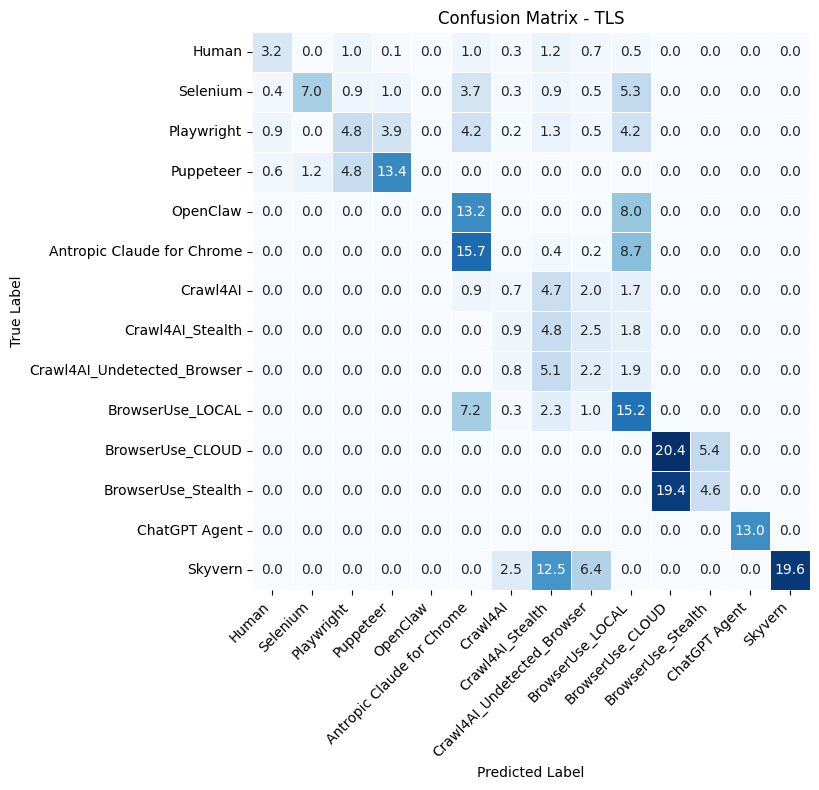

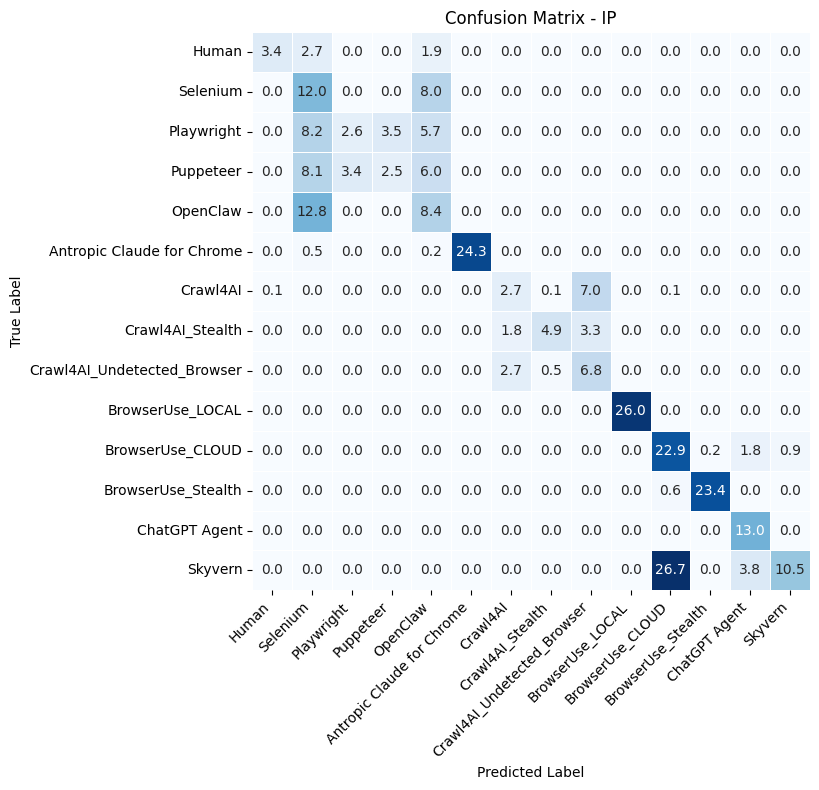

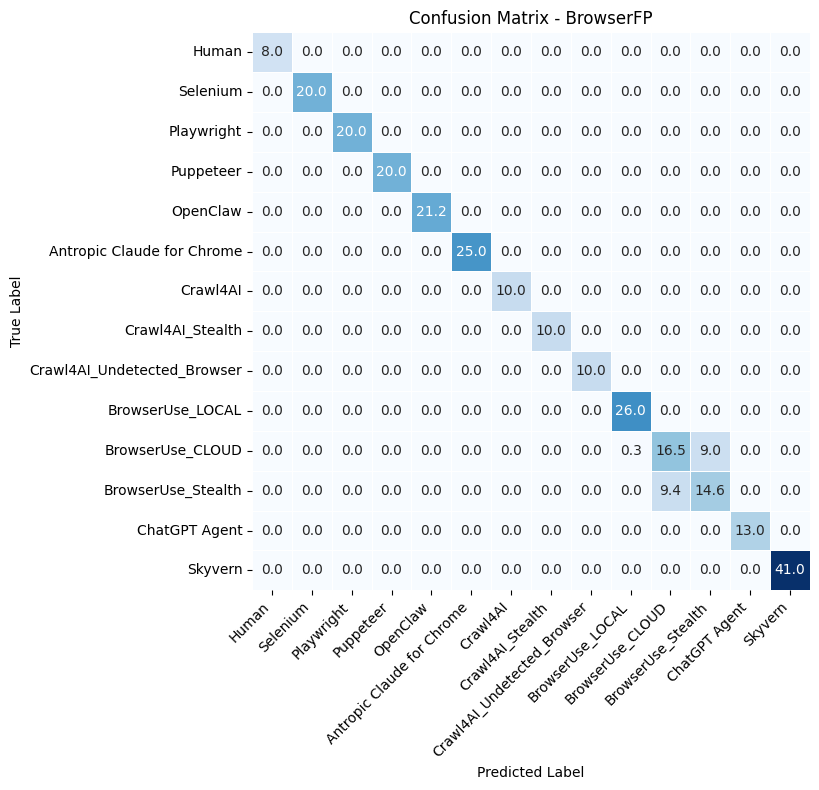

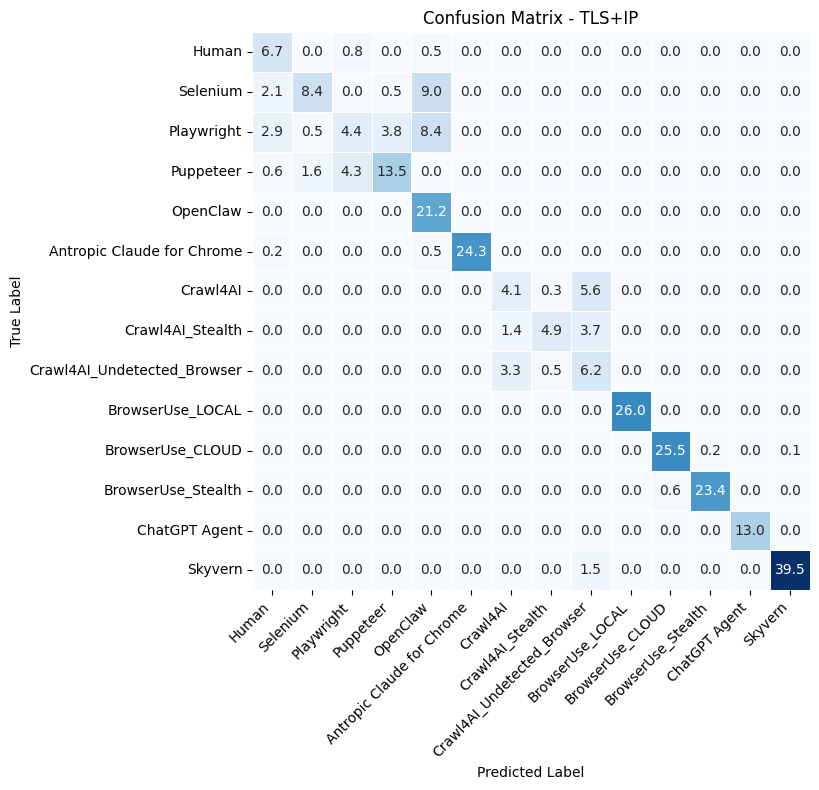

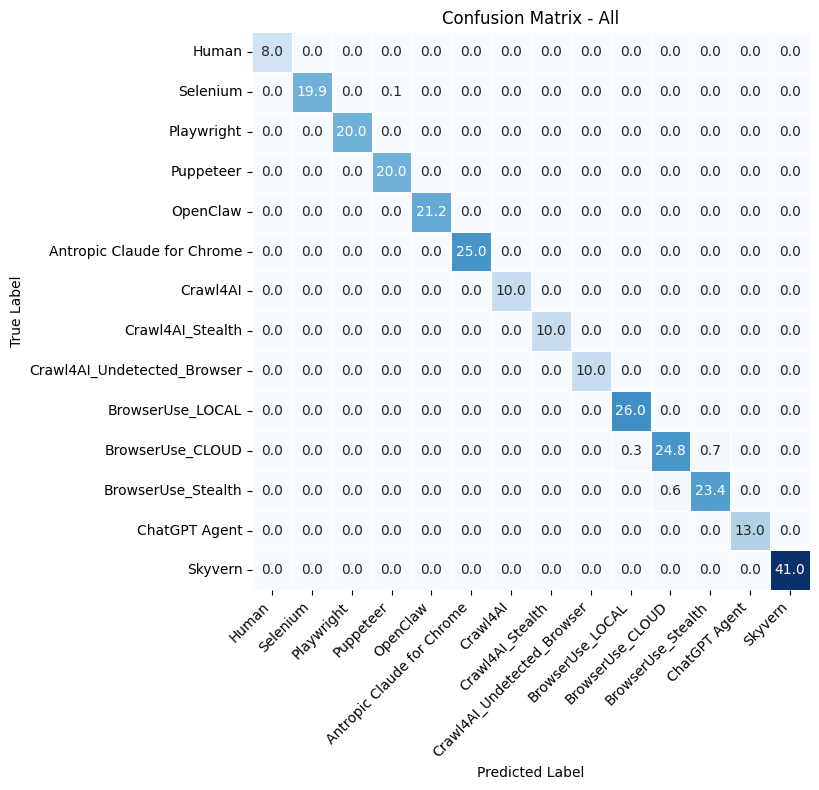

In [ ]:
# Loop over catboost_results_seeds elements
for index, row in catboost_results_seeds.iterrows():
    row.head()
    plot_confusion_matrix(
        cm =row["cm_mean"],  # Extract the mean confusion matrix for this layer
        labels=LABELS,
        title=f"Confusion Matrix - {row['layer']}",
        normalize=True, 
        save_path=f"{row['layer']}_mean_matrix.svg",
        fmt=".1f"
    )